# Load model checkpoint and evaluate performance

In [1]:
import torch
import sys
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO, event_representations
from topspin_datamodule import TopspinDataModule, pad_collate_fn
from topspin_classification_module import TopspinLitModule
from TOPSPIN import Hdf5Dataset
from tqdm import tqdm
import numpy as np

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load checkpoint

In [3]:
#checpoint_path = "../logs/train/runs/" + "2025-09-10_20-13-05/" + "checkpoints/" + "epoch_034.ckpt"

# model with new data
checpoint_path = "../logs/train/runs/" + "2025-09-23_15-00-26/" + "checkpoints/" + "last.ckpt"

# model = torch.load(checpoint_path, map_location=torch.device('cpu'), weights_only=False)
model = TopspinLitModule.load_from_checkpoint(checpoint_path)

In [4]:
data_module = TopspinDataModule(
    data_dir="/data/lkolmar/datasets/topspin_fit_to_max/",
    time_window=5000,  # in us
    num_bins=10,
    sensor_size=(100, 100),
    train_val_test_split=(1294, 277, 277),  # n = 1848 (70%, 15%, 15%)
    batch_size=8,
    num_workers=4,
    pin_memory=True,
)
data_module.prepare_data()
data_module.setup()
test_loader = data_module.test_dataloader()

Flipped: False

------------------------------------------------------------------------

Train indices: [1590, 1, 1334, 52, 954, 1596, 298, 1188, 78, 440, 1790, 1297, 722, 952, 771, 895, 1347, 1761, 1515, 530, 377, 119, 603, 1434, 323, 1001, 221, 1440, 1255, 1247, 636, 600, 443, 1177, 211, 1792, 755, 1579, 1070, 870, 1810, 800, 985, 362, 1199, 353, 383, 1236, 741, 1041, 1492, 1527, 626, 1647, 1624, 1027, 1399, 665, 376, 421, 1370, 1796, 1652, 313, 510, 427, 171, 1703, 799, 1513, 963, 1226, 1648, 1051, 842, 1805, 1107, 1038, 986, 470, 174, 775, 1408, 426, 1474, 1340, 283, 123, 1083, 1169, 511, 2, 509, 567, 1839, 1830, 625, 944, 459, 308, 554, 1127, 453, 1023, 105, 1812, 1651, 95, 1093, 357, 319, 102, 1343, 1459, 1016, 1189, 840, 1231, 289, 493, 1223, 23, 441, 1769, 916, 80, 1503, 846, 587, 551, 1655, 1101, 980, 1458, 74, 433, 776, 1235, 138, 1714, 979, 1542, 1523, 417, 1207, 700, 1312, 695, 1316, 1184, 1012, 540, 1336, 871, 1478, 642, 546, 431, 1348, 1747, 1206, 731, 937, 1355, 1397, 1

In [5]:
test_dataset = Hdf5Dataset(
    dataset_path="/data/lkolmar/datasets/topspin_fit_to_max/",
    indices=[229, 1637, 1827, 315, 1373, 1100, 810, 160, 1573, 864, 1516, 837, 586, 341, 361, 527, 881, 1125, 158, 1677, 874, 1245, 1301, 503, 1508, 995, 99, 19, 278, 76, 851, 919, 342, 1383, 127, 1759, 927, 88, 1834, 1498, 556, 129, 462, 1585, 1078, 911, 293, 114, 1267, 943, 214, 526, 1595, 196, 5, 330, 299, 716, 679, 331, 1711, 733, 372, 126, 1461, 703, 77, 474, 1415, 647, 1471, 1786, 45, 494, 153, 1094, 696, 30, 1172, 833, 1625, 725, 1111, 1420, 1375, 657, 1056, 879, 452, 961, 547, 1281, 1543, 1241, 1806, 230, 403, 173, 1254, 1787, 1028, 681, 117, 304, 1636, 1050, 314, 869, 1752, 699, 710, 1258, 1164, 258, 896, 1190, 1351, 287, 797, 1432, 1746, 1230, 1080, 496, 1644, 1613, 1413, 9, 379, 780, 1463, 1754, 410, 565, 337, 1322, 356, 1359, 206, 40, 236, 1087, 1483, 1137, 905, 928, 1119, 1833, 20, 1314, 1043, 1047, 621, 1280, 708, 845, 1591, 415, 1841, 618, 1386, 268, 1151, 251, 913, 14, 652, 409, 885, 1112, 1157, 844, 1737, 1757, 557, 327, 429, 1428, 1382, 324, 328, 920, 693, 1072, 904, 1820, 581, 434, 882, 1320, 306, 1082, 1657, 1465, 1845, 1574, 976, 854, 1318, 1146, 777, 1067, 1568, 778, 448, 1426, 991, 343, 505, 1817, 951, 163, 1692, 588, 1672, 1088, 1532, 1075, 764, 1704, 892, 1342, 491, 532, 1545, 1477, 190, 975, 633, 1748, 340, 1439, 694, 1836, 820, 1035, 935, 109, 1561, 827, 1615, 238, 242, 121, 98, 43, 1819, 1039, 1631, 262, 111, 212, 1707, 295, 576, 75, 203, 534, 1401, 329, 155, 1641, 159, 108, 1393, 1357, 713, 676, 1744, 435, 924, 255, 1055, 285, 252, 1528, 21],
    transforms=data_module.transforms
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=pad_collate_fn
)

In [5]:
# Use Real Dataset

test_dataset = Hdf5Dataset(
    dataset_path="/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/",
    indices=np.arange(0, 118),
    transforms=data_module.transforms
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=pad_collate_fn
)

In [6]:
labels_names = {
    "topspin_slow": 0,
    "topspin_mid": 1,
    "topspin_fast": 2,
    "backspin_slow": 3,
    "backspin_mid": 4,
    "backspin_fast": 5,
}

In [7]:
print("Number of test samples:", len(test_loader.dataset))
samples_per_class = [0, 0, 0, 0, 0, 0]
for c in range(len(test_loader.dataset)):
    label = test_loader.dataset[c][1]
    samples_per_class[label] += 1

print("Samples per class:", samples_per_class)

Number of test samples: 118
Samples per class: [42, 22, 22, 12, 20, 0]


In [8]:
for batch in test_loader:
    break
print(len(batch))

3


In [9]:
data, lenghts, label = batch
print("Data shape:", data.shape)
print("Lengths shape:", lenghts.shape)
print("Label shape:", label.shape)

Data shape: torch.Size([8, 25, 10, 100, 100])
Lengths shape: torch.Size([8])
Label shape: torch.Size([8])


# Get predictions

In [8]:
# [index, label, prediction]
predictions = []
model.eval()
model.to("cpu")

with torch.no_grad():
    for batch in test_loader:
        data, lengths, label = batch
        # print(batch)

        logits = model.net(data.to("cpu"), lengths.to("cpu"))
        logits = np.argmax(logits.cpu().numpy(), axis=1)
        print("Logits:", logits)
        print("Label:", label.numpy())

        predictions.extend(zip(logits, label.numpy()))

print(predictions[:10])  # Print first 10 predictions

Logits: [5 5 5 5 2 5 2 1]
Label: [0 0 0 0 0 0 0 0]
Logits: [5 5 5 5 5 5 2 5]
Label: [0 0 0 0 0 0 0 0]
Logits: [5 5 5 5 5 5 2 5]
Label: [0 0 0 0 0 0 0 0]
Logits: [5 5 5 5 5 5 5 5]
Label: [0 0 0 0 0 0 0 0]
Logits: [5 5 5 5 5 5 2 5]
Label: [0 0 0 0 0 0 0 0]
Logits: [5 5 5 5 5 5 5 5]
Label: [0 0 1 1 1 1 1 1]
Logits: [1 5 5 1 5 2 5 5]
Label: [1 1 1 1 1 1 1 1]
Logits: [5 5 5 5 5 2 5 5]
Label: [1 1 1 1 1 1 2 2]
Logits: [1 5 5 5 5 1 5 5]
Label: [2 2 2 2 2 2 2 2]
Logits: [5 5 5 5 5 5 5 2]
Label: [2 2 2 2 2 2 2 2]
Logits: [5 5 5 5 5 5 2 5]
Label: [2 2 3 3 3 3 3 3]
Logits: [5 5 5 5 5 5 2 5]
Label: [3 3 3 3 3 3 4 4]
Logits: [2 5 5 5 5 5 5 5]
Label: [4 4 4 4 4 4 4 4]
Logits: [5 5 5 5 5 5 2 5]
Label: [4 4 4 4 4 4 4 4]
Logits: [1 5 5 5 5 5]
Label: [4 4 1 1 2 2]
[(5, 0), (5, 0), (5, 0), (5, 0), (2, 0), (5, 0), (2, 0), (1, 0), (5, 0), (5, 0)]


# Create Matrix

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix:
[[ 0  1  5  0  0 36]
 [ 0  2  2  0  0 18]
 [ 0  2  1  0  0 19]
 [ 0  0  1  0  0 11]
 [ 0  1  3  0  0 16]
 [ 0  0  0  0  0  0]]


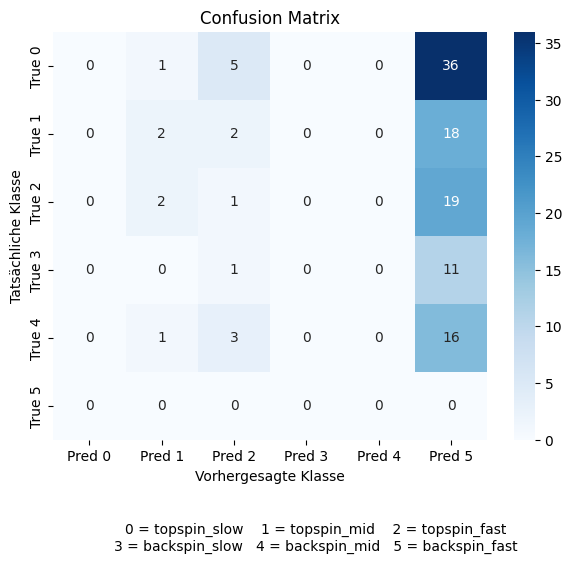

In [10]:
# preds = [(p + 3) % 6 for p,l in predictions]
preds = [p for p,l in predictions]
labels = [l for p,l in predictions]

cm = confusion_matrix(labels, preds, labels=list(range(6)))
print("Confusion Matrix:")
print(cm)

# Schöne Visualisierung
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[f"Pred {i}" for i in range(6)],
            yticklabels=[f"True {i}" for i in range(6)])
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.title("Confusion Matrix")

plt.subplots_adjust(bottom=0.2)  # extra Platz unten

# Beschreibung der Klassen unterhalb einfügen
label_text = (
    "0 = topspin_slow    1 = topspin_mid    2 = topspin_fast\n"
    "3 = backspin_slow   4 = backspin_mid   5 = backspin_fast"
)
plt.figtext(0.5, 0.02, label_text, 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()

# Check why

In [11]:
from player import VideoPlayer

In [14]:
# idx class 5 (real, sim) -> (100, 28)
# idx class 2 (real, sim) -> (50, 0)
path_real5 = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(100).zfill(5)}/{str(100).zfill(5)}_roi.hdf5"
path_sim5 = f"/data/lkolmar/datasets/topspin_fit_to_max/preprocessed/{str(28).zfill(5)}/{str(28).zfill(5)}_roi.hdf5"

path_real2 = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(50).zfill(5)}/{str(50).zfill(5)}_roi.hdf5"
path_sim2 = f"/data/lkolmar/datasets/topspin_fit_to_max/preprocessed/{str(0).zfill(5)}/{str(0).zfill(5)}_roi.hdf5"

In [17]:
path = path_real5
buf = eventIO.load_hdf5(path)    
frames = eventIO.buffer_to_video(buf, tw_us=1000)

/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in divide
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)
/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in cast
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)


In [ ]:
app = VideoPlayer(frames, fps=30)
app.mainloop()

KeyboardInterrupt: 

: 

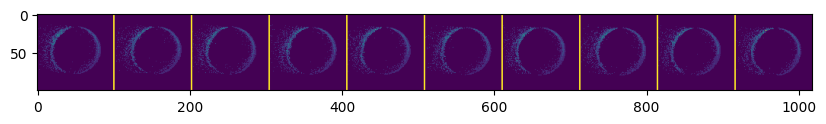

In [80]:
buf = eventIO.load_hdf5(path_real5)
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
plt.figure(figsize=(10, 5))
plt.imshow(event_representations.get_voxel_grid_as_image(seq[13]))
plt.show()

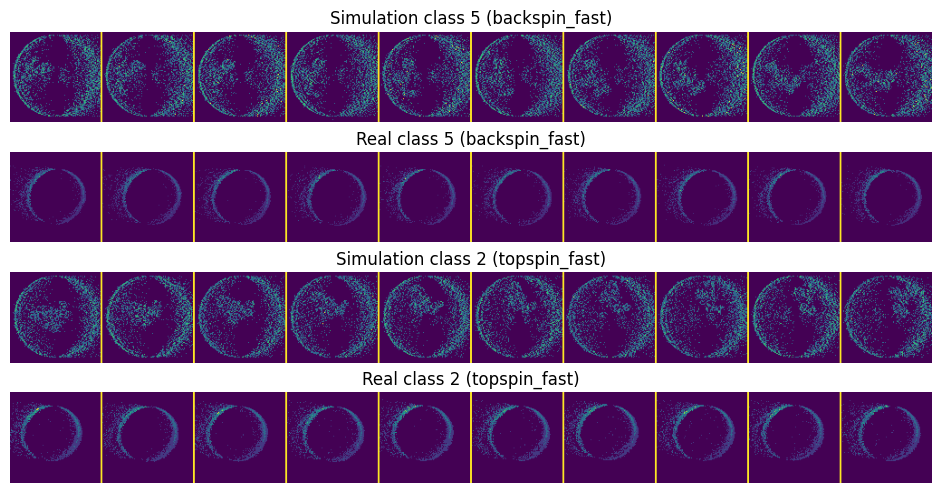

In [63]:
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
fig, axes = plt.subplots(4, 1, figsize=(10, 5))

buf = eventIO.load_hdf5(path_sim5)
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
axes[0].imshow(event_representations.get_voxel_grid_as_image(seq[20]))
axes[0].set_title("Simulation class 5 (backspin_fast)")
axes[0].axis('off')

buf = eventIO.load_hdf5(path_real5)
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
axes[1].imshow(event_representations.get_voxel_grid_as_image(seq[20]))
axes[1].set_title("Real class 5 (backspin_fast)")
axes[1].axis('off')

buf = eventIO.load_hdf5(path_sim2)
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
axes[2].imshow(event_representations.get_voxel_grid_as_image(seq[20]))
axes[2].set_title("Simulation class 2 (topspin_fast)")
axes[2].axis('off')

buf = eventIO.load_hdf5(path_real2)
seq = event_representations.create_sequence(eventIO.buffer_to_array(buf), 5000, 10, (100, 100))
axes[3].imshow(event_representations.get_voxel_grid_as_image(seq[20]))
axes[3].set_title("Real class 2 (topspin_fast)")
axes[3].axis('off')

plt.tight_layout()
plt.show()